# DDPM Tasks 0-2 (Barebones MNIST)


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

from src.config import get_device
from src.data import get_mnist_dataloader, run_task0
from src.diffusion.forward import forward_moment_sanity_check, q_sample
from src.diffusion.posterior import q_posterior_mean_variance
from src.diffusion.schedule import build_schedule, make_beta_schedule, snr
from src.utils.viz import plot_schedule


## Task 0:

In [2]:
task0_stats = run_task0()
task0_stats

{'shape': (128, 1, 28, 28),
 'dtype': 'torch.float32',
 'min': -1.0,
 'max': 1.0,
 'labels_min': 0,
 'labels_max': 9,
 'grid_path': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task0_real_grid.png'}

## Task 1:


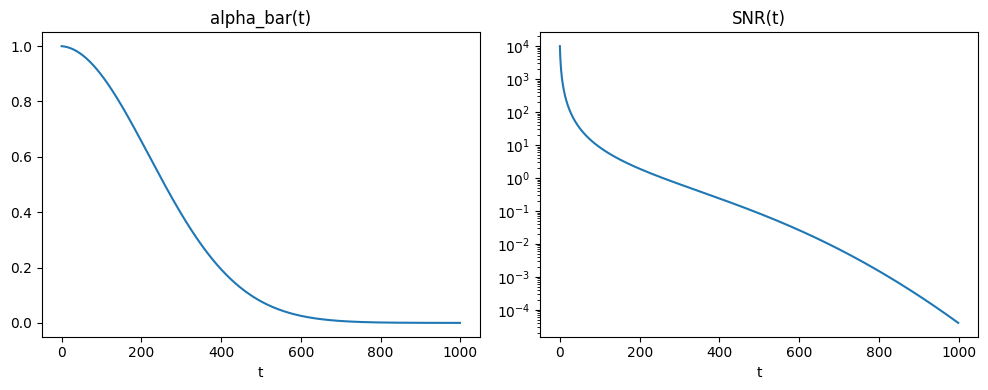

schedule type: linear
timesteps: 1000
beta min/max: 9.999999747378752e-05 0.019999999552965164
beta tensor shape: (1000,)


In [3]:
device = get_device()
schedule = build_schedule(device=device, schedule_type="linear")
plot_schedule(schedule.alpha_bars, snr(schedule))
print("schedule type:", schedule.schedule_type)
print("timesteps:", schedule.timesteps)
print("beta min/max:", float(schedule.betas.min()), float(schedule.betas.max()))

# API parity with assignment prompt: make_beta_schedule(L, type, beta_min, beta_max)
betas_check = make_beta_schedule(
    timesteps=schedule.timesteps,
    schedule_type="linear",
    beta_start=1e-4,
    beta_end=2e-2,
    device=device,
)
print("beta tensor shape:", tuple(betas_check.shape))


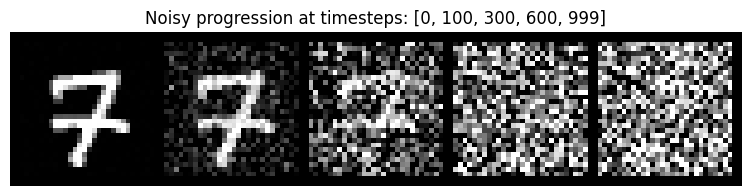

In [4]:
loader = get_mnist_dataloader(batch_size=1, train=True, shuffle=True)
x0, _ = next(iter(loader))
x0 = x0.to(device)

steps = [0, 100, 300, 600, 999]
images = []
for step in steps:
    t = torch.tensor([step], device=device, dtype=torch.long)
    xt = q_sample(x0, t, schedule)
    images.append(xt.cpu())

stacked = torch.cat(images, dim=0)
grid = make_grid((stacked.clamp(-1, 1) + 1.0) * 0.5, nrow=len(steps))
plt.figure(figsize=(12, 2))
plt.axis("off")
plt.title(f"Noisy progression at timesteps: {steps}")
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.show()

Verify

In [5]:
moment_stats = forward_moment_sanity_check(
    x0=x0,
    timestep=300,
    schedule=schedule,
    num_trials=2048,
)
moment_stats


{'timestep': 300.0,
 'num_trials': 2048.0,
 'empirical_mean_global': -0.44448404549238457,
 'theoretical_mean_global': -0.44537023057716235,
 'empirical_var_global': 0.606529341354386,
 'theoretical_var_global': 0.6059889793395996,
 'mean_abs_error_mean': 0.014338008093233682,
 'mean_abs_error_var': 0.015641886013207082,
 'max_abs_error_mean': 0.059991355577949435,
 'max_abs_error_var': 0.06507413120919059}

## Task 2: Posterior quantities

In [6]:
print("All posterior variances > 0:", bool((schedule.posterior_variance > 0).all()))
print("For t>=1, posterior variance < beta:", bool((schedule.posterior_variance[1:] < schedule.betas[1:]).all()))

x0_batch, _ = next(iter(get_mnist_dataloader(batch_size=16, train=True, shuffle=True)))
x0_batch = x0_batch.to(device)
t = torch.randint(1, schedule.timesteps, (x0_batch.shape[0],), device=device)
noise = torch.randn_like(x0_batch)
xt = q_sample(x0_batch, t, schedule, noise)
mean, var = q_posterior_mean_variance(x0_batch, xt, t, schedule)

print("Posterior mean shape:", tuple(mean.shape))
print("Posterior var min/max:", float(var.min()), float(var.max()))

All posterior variances > 0: True
For t>=1, posterior variance < beta: True
Posterior mean shape: (16, 1, 28, 28)
Posterior var min/max: 0.0009973675478249788 0.019860543310642242
